In [37]:
import os
import shutil
import cv2
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

1. Clasificar las imagenes del train usando Kmeans en 0 y 1 (Imágenes con y sin mariposas)
2. Guardo los 2 clusters en carpetas separadas
3. Ver a partir de ah

In [2]:
init_train_path = r'X:\CODING\PROJECTS\BUTTERFLY\train' # First imgs for training
init_test_path = r'X:\CODING\PROJECTS\BUTTERFLY\test' # First imgs for testing

In [3]:
# FOR TRAINING IMGS
i=0
j=0
for file in os.listdir(init_train_path):
  j+=1
  if ".jpeg" in file:
    i+=1
print(f"Imgs with a butterfly on TRAIN --> {i}") #This means there are 1031 imgs WITH a butterfly out of 3312
print(f"Total imgs on TRAIN --> {j}")

print("")
print("")
# FOR TESTING IMGS
k=0
l=0
for file in os.listdir(init_test_path):
  l+=1
  if ".jpeg" in file:
    k+=1
print(f"Imgs with a butterfly on TEST --> {k}") #This means there are 1031 imgs WITH a butterfly out of 3312
print(f"Total imgs on TEST --> {l}")

Imgs with a butterfly on TRAIN --> 1031
Total imgs on TRAIN --> 3312


Imgs with a butterfly on TEST --> 456
Total imgs on TEST --> 900


Knowing the imgs with and without a butterfly,
1. We will firstly use a KMeans algorythm to check it out.
2. Then we will separate by using OS library the imgs so we can see the difference

In [4]:
target_size= (100,100)
img_path = []
train_imgs= os.listdir(init_train_path)

In [5]:
train_file_paths = [os.path.join(init_train_path, f) for f in os.listdir(init_train_path)]

train_imgs_list = []
for i in train_file_paths:
  img = cv2.imread(i)
  img = cv2.resize(img, (256,256))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  img = img/255.0
  train_imgs_list.append(img)
# train_imgs_list

# Now for the Test
test_file_paths = [os.path.join(init_test_path, f) for f in os.listdir(init_test_path)]

test_imgs_list = []
for i in test_file_paths:
  img = cv2.imread(i)
  img = cv2.resize(img, (256,256))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  img = img/255.0    
  test_imgs_list.append(img)
# test_imgs_list

In [6]:
pickle_path = r"X:\CODING\PROJECTS\BUTTERFLY"

In [7]:
# Save imgs_list as a pickle file so we do not have to load it
with open('train_imgs_list.plk', 'wb') as f:
        pickle.dump(train_imgs_list, f)

with open('test_imgs_list.plk', 'wb') as f:
        pickle.dump(test_imgs_list, f)

In [3]:
# Load the pickle imgs_list
with open('train_imgs_list.plk', "rb") as f:
    train_imgs_list = pickle.load(f)

with open('test_imgs_list.plk', "rb") as f:
    test_imgs_list = pickle.load(f)

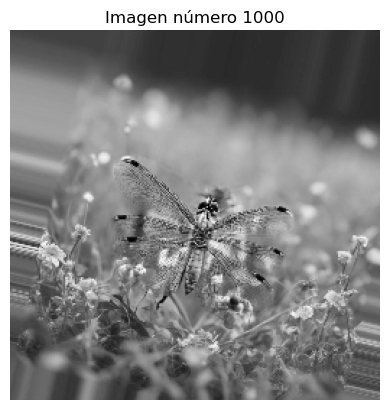

In [4]:
import matplotlib.pyplot as plt
i=1000
plt.imshow(train_imgs_list[i], cmap = 'gray')
plt.title(f"Imagen número {i}")
plt.axis("off")
plt.show()

In [5]:
def check_size(list, list_name):
    shapes = [img.shape for img in list]
    single_shapes = set(shapes)
    print(f"{list_name} tiene {len(single_shapes)} single shapes:")
    for i, shape in enumerate(single_shapes):
        print(f"  - Shape {i+1}: {shape}")
    return single_shapes

In [6]:
tamanos_train = check_size(train_imgs_list, "train_imgs_list")
tamanos_test = check_size(test_imgs_list, "test_imgs_list")

train_imgs_list tiene 1 single shapes:
  - Shape 1: (256, 256)
test_imgs_list tiene 1 single shapes:
  - Shape 1: (256, 256)


In [7]:
all_imgs=train_imgs_list+test_imgs_list
all_imgs=np.array(all_imgs)
all_imgs_flat=all_imgs.reshape(len(all_imgs), -1)
all_imgs_flat.shape

(4212, 65536)

In [8]:
# We use the Elbow Method so we can get the best of number of clusters

C:\Users\ivanp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\ivanp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\ivanp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\ivanp\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

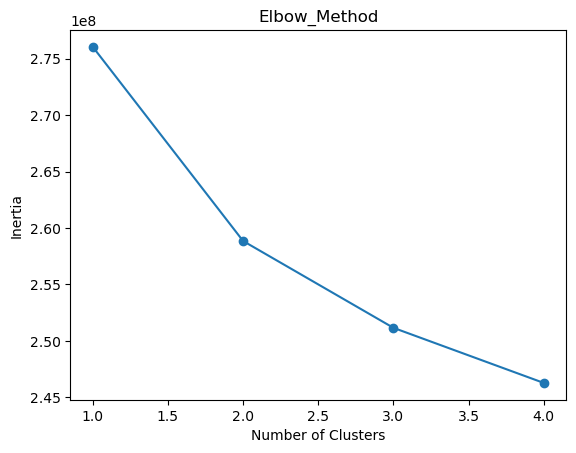

In [78]:
inertia = []
k_range = range(1,5)

for k in k_range:
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(all_imgs_flat)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow_Method')
plt.show()

As we predicted earlier by having a look at the dataset, the optimal number of clusters are 2

In [9]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(all_imgs_flat)
labels = kmeans.labels_

Create directories for the 2 clusters (0 and 1) where there are and not butterflies on the pic (this will be tested ahead)

Separate imgs by cluster

In [10]:
clusters_0_imgs = []
clusters_1_imgs = []

for i, label in enumerate(labels):
    if label == 0:
        clusters_0_imgs.append(all_imgs[i])
    else:
        clusters_1_imgs.append(all_imgs[i])

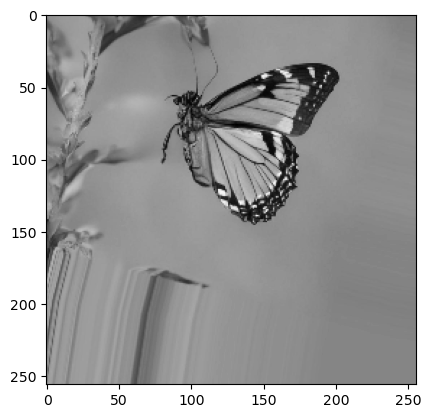

In [45]:
plt.imshow(clusters_1_imgs[700],cmap = 'gray' )
plt.show()

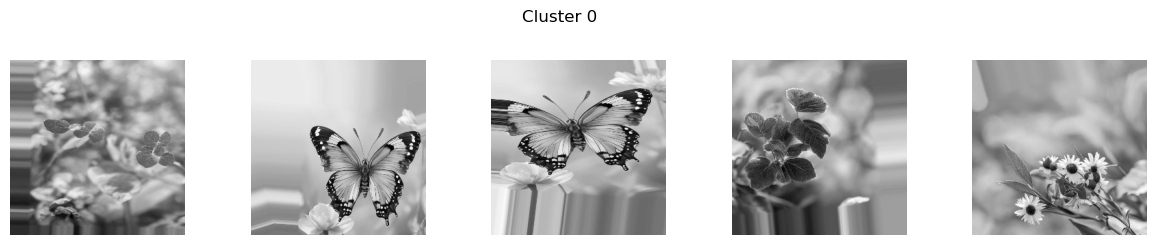

In [36]:
plt.figure(figsize=(15, 5))

for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(clusters_1_imgs[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Cluster 0")
plt.show()

As we have imgs with butterflies in both categories that kmeans gave us, we are going to try with PCA reducing to 2D just to see if the clusters get separated